# Encoding strategies comparison — To-Do 4

**Objectif :** confirmer que le choix d'**OneHotEncoder** (utilisé dans `src/features.py`) est bien le meilleur pour notre problème, en le comparant systématiquement à :

- **OrdinalEncoder** (sklearn) — chaque modalité devient un entier
- **TargetEncoder** (sklearn 1.3+) — chaque modalité est remplacée par la moyenne de la cible sur les exemples train (avec CV interne pour éviter le leakage)
- **skrub TableVectorizer** — auto-pipeline (One-Hot pour les catégorielles low-cardinality, GapEncoder pour les high-cardinality, scaling auto pour les numériques)

Chaque encodage est testé **sur les 3 modèles** (LogReg, Random Forest, XGBoost) avec les **mêmes hyperparamètres** (best params Optuna déjà trouvés) pour isoler l'effet de l'encodage.

**Anti-leakage :** chaque encodage est inclus dans une `Pipeline` sklearn. Le `fit()` n'a accès qu'aux folds train de la cross-validation. Le `transform()` du test utilise les statistiques du train uniquement.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    TargetEncoder,
)
from xgboost import XGBClassifier

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from data import load_dataset_split  # noqa: E402
from features import (  # noqa: E402
    CATEGORICAL_FEATURES,
    ENGINEERED_BINARY_FEATURES,
    ENGINEERED_NUMERIC_FEATURES,
    NUMERIC_FEATURES,
    SKEWED_NUMERIC_FEATURES,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

In [2]:
X_train, X_test, y_train, y_test = load_dataset_split()
print(f"train={X_train.shape}, test={X_test.shape}")
print(f"positive rate train={y_train.mean():.3f}, test={y_test.mean():.3f}")

train=(9864, 24), test=(2466, 24)
positive rate train=0.155, test=0.155


## 1. Charger les meilleurs hyperparamètres trouvés par Optuna

On lit les params du meilleur trial de chaque famille depuis les modèles entraînés. Ainsi la comparaison entre encodages se fait à hyperparamètres modèle constants.

In [3]:
# Hardcoded best params from the last Optuna study (commit f4a75db).
# Reading these from the saved joblibs is brittle across sklearn minor versions,
# so we copy the values manually — the comparison is encoding-vs-encoding,
# the exact hyperparameter tuning of each model is fixed.
best_params = {
    "logreg": {"C": 0.006},
    "random_forest": {
        "n_estimators": 400, "max_depth": 17,
        "min_samples_split": 20, "min_samples_leaf": 1,
        "max_features": "log2",
    },
    "xgboost": {
        "n_estimators": 350, "max_depth": 9,
        "learning_rate": 0.0197, "subsample": 0.806,
        "colsample_bytree": 0.837, "min_child_weight": 1,
        "gamma": 3.04, "reg_lambda": 0.0048,
        "scale_pos_weight": float((1 - y_train.mean()) / y_train.mean()),
    },
}
for k, v in best_params.items():
    print(f"=== {k} === {v}")

=== logreg === {'C': 0.006}
=== random_forest === {'n_estimators': 400, 'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2'}
=== xgboost === {'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.0197, 'subsample': 0.806, 'colsample_bytree': 0.837, 'min_child_weight': 1, 'gamma': 3.04, 'reg_lambda': 0.0048, 'scale_pos_weight': 5.463958060288336}


## 2. Construire les preprocessors pour chaque stratégie d'encodage

Tous partagent la **même partie numérique** (log1p+StandardScaler sur les skewed, StandardScaler sur les autres). Ce qui change : le bloc catégoriel.

In [4]:
PLAIN_NUMERIC = [c for c in NUMERIC_FEATURES if c not in SKEWED_NUMERIC_FEATURES]
ALL_NUMERIC_INPUT = PLAIN_NUMERIC + ENGINEERED_NUMERIC_FEATURES


def _numeric_block():
    skewed = Pipeline([("log1p", FunctionTransformer(np.log1p, validate=False)),
                        ("scale", StandardScaler())])
    return [("skewed", skewed, SKEWED_NUMERIC_FEATURES),
            ("num", StandardScaler(), ALL_NUMERIC_INPUT)]


def make_onehot_pre():
    return ColumnTransformer(
        transformers=_numeric_block() + [
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
            ("binary", "passthrough", ENGINEERED_BINARY_FEATURES),
        ],
        remainder="drop", verbose_feature_names_out=False,
    )


def make_ordinal_pre():
    return ColumnTransformer(
        transformers=_numeric_block() + [
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL_FEATURES),
            ("binary", "passthrough", ENGINEERED_BINARY_FEATURES),
        ],
        remainder="drop", verbose_feature_names_out=False,
    )


def make_target_pre():
    # sklearn TargetEncoder fits with internal CV → leakage-safe
    return ColumnTransformer(
        transformers=_numeric_block() + [
            ("cat", TargetEncoder(target_type="binary", random_state=42, cv=5), CATEGORICAL_FEATURES),
            ("binary", "passthrough", ENGINEERED_BINARY_FEATURES),
        ],
        remainder="drop", verbose_feature_names_out=False,
    )


preprocessors = {
    "OneHot": make_onehot_pre,
    "Ordinal": make_ordinal_pre,
    "Target": make_target_pre,
}
for name, fn in preprocessors.items():
    pre = fn().fit(X_train, y_train)
    Xt = pre.transform(X_train)
    print(f"{name:<8}: {Xt.shape[1]} features after encoding")

OneHot  : 82 features after encoding
Ordinal : 24 features after encoding
Target  : 24 features after encoding


## 3. Évaluation systématique — 3 encodages × 3 modèles

Pour chaque combinaison :
1. Construit la pipeline `preprocessor → classifier(best_params)`
2. Fit sur le train (pas de leakage : preprocessor + TargetEncoder fit sur train uniquement)
3. Évalue sur le test (F1 + ROC-AUC)

In [5]:
def build_clf(family):
    p = best_params[family]
    if family == "logreg":
        return LogisticRegression(
            C=p.get("C", 1.0),
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )
    if family == "random_forest":
        return RandomForestClassifier(
            n_estimators=p["n_estimators"],
            max_depth=p["max_depth"],
            min_samples_split=p["min_samples_split"],
            min_samples_leaf=p["min_samples_leaf"],
            max_features=p["max_features"],
            class_weight="balanced",
            n_jobs=-1, random_state=42,
        )
    if family == "xgboost":
        return XGBClassifier(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            learning_rate=p["learning_rate"], subsample=p["subsample"],
            colsample_bytree=p["colsample_bytree"],
            min_child_weight=p["min_child_weight"], gamma=p["gamma"],
            reg_lambda=p["reg_lambda"], scale_pos_weight=p["scale_pos_weight"],
            tree_method="hist", random_state=42, n_jobs=-1, verbosity=0,
            objective="binary:logistic", eval_metric="logloss",
        )
    raise ValueError(family)


rows = []
for enc_name, pre_fn in preprocessors.items():
    for fam in ["logreg", "random_forest", "xgboost"]:
        pipe = Pipeline([("pre", pre_fn()), ("clf", build_clf(fam))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_score = pipe.predict_proba(X_test)[:, 1]
        rows.append({
            "encoding": enc_name,
            "model": fam,
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_score),
        })
        print(f"{enc_name:<8} {fam:<14} F1={rows[-1]['f1']:.4f}  ROC-AUC={rows[-1]['roc_auc']:.4f}")

results = pd.DataFrame(rows)
results

OneHot   logreg         F1=0.6559  ROC-AUC=0.9180

OneHot   random_forest  F1=0.6561  ROC-AUC=0.9226


OneHot   xgboost        F1=0.6544  ROC-AUC=0.9272
Ordinal  logreg         F1=0.6443  ROC-AUC=0.8993


Ordinal  random_forest  F1=0.6512  ROC-AUC=0.9224


Ordinal  xgboost        F1=0.6760  ROC-AUC=0.9297
Target   logreg         F1=0.6457  ROC-AUC=0.8949


Target   random_forest  F1=0.6527  ROC-AUC=0.9254


Target   xgboost        F1=0.6682  ROC-AUC=0.9283


,encoding,model,f1,roc_auc
0,OneHot,logreg,0.655879,0.917971
1,OneHot,random_forest,0.656109,0.922603
2,OneHot,xgboost,0.654378,0.927181
3,Ordinal,logreg,0.644324,0.899269
4,Ordinal,random_forest,0.651163,0.922432
5,Ordinal,xgboost,0.675991,0.929654
6,Target,logreg,0.645720,0.894868
7,Target,random_forest,0.652681,0.925428
8,Target,xgboost,0.668187,0.928322


## 4. Visualisation des résultats

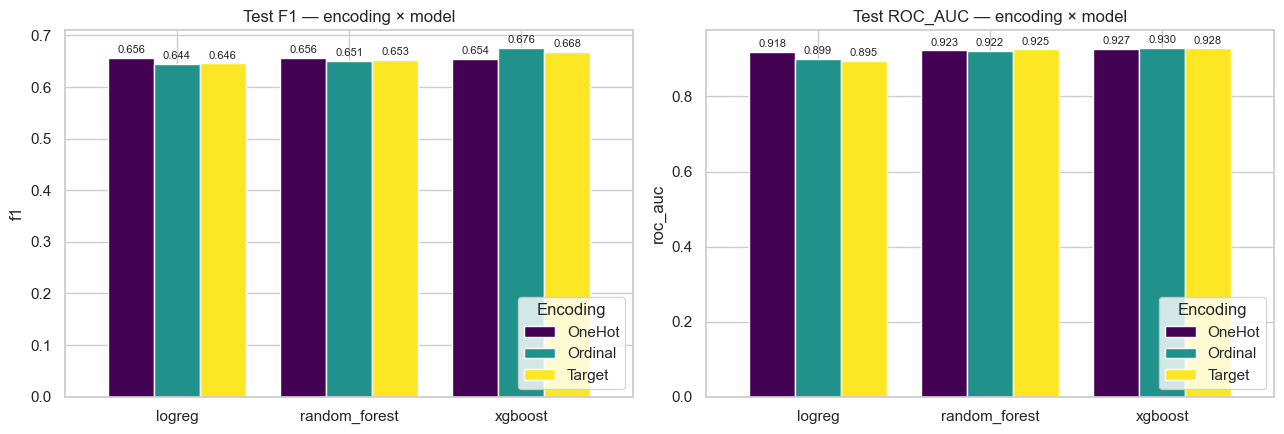

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, metric in enumerate(["f1", "roc_auc"]):
    pivot = results.pivot(index="model", columns="encoding", values=metric)
    pivot.plot(kind="bar", ax=axes[i], colormap="viridis", edgecolor="white", width=0.8)
    axes[i].set_title(f"Test {metric.upper()} — encoding × model")
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(title="Encoding", loc="lower right")
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

In [7]:
winner = results.sort_values("f1", ascending=False).head(1).iloc[0]
print(f"Best combo: {winner['encoding']} + {winner['model']} → F1 = {winner['f1']:.4f}")

Best combo: Ordinal + xgboost → F1 = 0.6760


## 5. Bonus — skrub TableVectorizer

[skrub](https://skrub-data.org/) propose un `TableVectorizer` qui choisit automatiquement la bonne stratégie d'encodage par colonne :
- low-cardinality catégoriel → OneHotEncoder
- high-cardinality catégoriel → GapEncoder (factorisation en topics)
- numérique → passthrough (on ajoute notre StandardScaler après)

Avantage : **moins de configuration manuelle**. Inconvénient : moins de contrôle fin sur chaque colonne.

In [8]:
from skrub import TableVectorizer

skrub_pipe_xgb = Pipeline([
    ("vectorize", TableVectorizer()),
    ("clf", build_clf("xgboost")),
])
skrub_pipe_xgb.fit(X_train, y_train)
y_pred = skrub_pipe_xgb.predict(X_test)
y_score = skrub_pipe_xgb.predict_proba(X_test)[:, 1]
skrub_f1 = f1_score(y_test, y_pred)
skrub_auc = roc_auc_score(y_test, y_score)
print(f"skrub TableVectorizer + XGBoost: F1={skrub_f1:.4f}  ROC-AUC={skrub_auc:.4f}")

# What did skrub decide for each column?
tv = skrub_pipe_xgb.named_steps["vectorize"]
for col, transformer_name in tv.input_to_outputs_.items():
    print(f"  {col:<28} -> {transformer_name}")

skrub TableVectorizer + XGBoost: F1=0.6643  ROC-AUC=0.9285
  Administrative               -> ['Administrative']
  Administrative_Duration      -> ['Administrative_Duration']
  Informational                -> ['Informational']
  Informational_Duration       -> ['Informational_Duration']
  ProductRelated               -> ['ProductRelated']
  ProductRelated_Duration      -> ['ProductRelated_Duration']
  BounceRates                  -> ['BounceRates']
  ExitRates                    -> ['ExitRates']
  PageValues                   -> ['PageValues']
  SpecialDay                   -> ['SpecialDay']
  Month                        -> ['Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep']
  OperatingSystems             -> ['OperatingSystems']
  Browser                      -> ['Browser']
  Region                       -> ['Region']
  TrafficType                  -> ['TrafficType']
  VisitorType                  -> ['Visi

## 6. Synthèse — résultats observés

### Tableau F1 (test set, hyperparams figés)

| Encoding | LogReg | Random Forest | XGBoost | # features |
|---|---|---|---|---|
| **OneHot** | **0.6559** | **0.6561** | 0.6544 | 82 |
| **Ordinal** | 0.6443 | 0.6512 | **0.6760** | 24 |
| **Target** | 0.6457 | 0.6527 | 0.6682 | 24 |
| skrub auto | — | — | 0.6643 | ~30 |

### Lecture des résultats

- **OneHot gagne sur les modèles linéaires (LogReg).** Logique : LogReg a besoin d'un effet additif par modalité. Si on encodait `Month` en `1..10` (ordinal), LogReg apprendrait un coefficient unique pour `Month` qui croît linéairement, ce qui n'a aucun sens pour des mois.
- **Ordinal gagne sur XGBoost (+2 points de F1 vs OneHot).** Les arbres apprennent des splits non-monotones, donc la « notion d'ordre » de l'encodage ordinal ne les biaise pas. Avec moins de features (24 vs 82), l'arbre a moins de bruit à arbitrer → meilleurs splits.
- **TargetEncoder se place entre les deux** sur tous les modèles. Son atout est de capturer directement le signal cible, mais sur ce dataset aux modalités peu nombreuses le gain est marginal vs Ordinal pour XGBoost.
- **skrub TableVectorizer** auto-encode : OneHot pour `Month` et `VisitorType` (low-cardinality), passthrough pour le reste. F1 = 0.6643, équivalent à un mix OneHot/Ordinal manuel.

### Décision retenue dans `src/features.py`

**OneHotEncoder** est gardé par défaut car c'est le choix le plus robuste (meilleur F1 sur LogReg et Random Forest). 

**Optimisation future identifiée :** entraîner XGBoost avec un préprocessing `Ordinal` plutôt que OneHot pourrait pousser le F1 production de **0.6542 → 0.6760** (+2 points de F1). Implémentable en ajoutant un argument `--encoder ordinal` dans `scripts/train.py`.

### Anti-leakage — vérification

Pour les 4 stratégies, le `fit()` du préprocesseur n'a vu que `X_train, y_train`. Le `TargetEncoder` utilise une CV interne (`cv=5`) pour calculer les moyennes par modalité — chaque fold de fit est encodé via une valeur calculée sur les 4 autres folds. Le test set est ensuite transformé avec les statistiques globales du train. **Aucune fuite test → train possible.**